# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

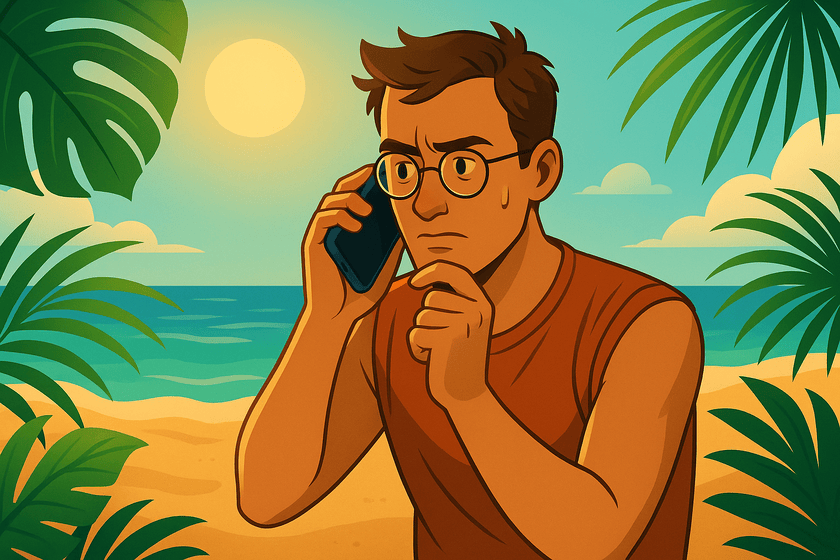

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


data_path = '/content/drive/MyDrive/ML/titanic.csv'
titanic_df = pd.read_csv(data_path)
titanic_df=titanic_df.drop(columns=['PassengerId','Name','Ticket','Cabin'])
print(titanic_df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


Predykowaną zmienną jest zmienna survived.

## Obsługa brakujących wartości:

In [6]:
print(titanic_df.isna().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare         98
Embarked      2
dtype: int64


<Axes: >

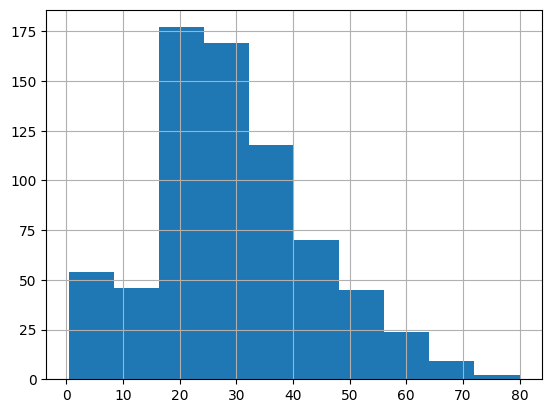

In [7]:
titanic_df["Age"].hist()


Zmienna ma rozkład asymetryczny

<Axes: >

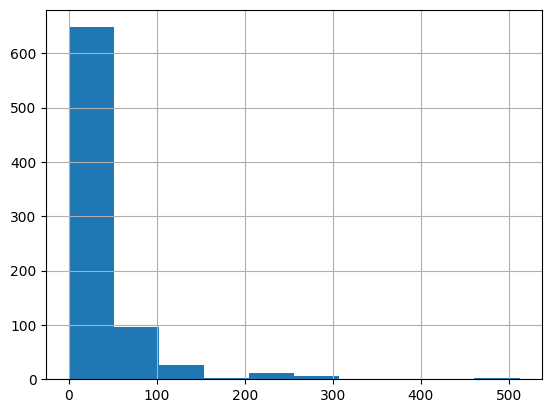

In [8]:
titanic_df["Fare"].hist()

Zmienna ma rozkład asymetryczny

In [9]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df['Fare'].median())

titanic_df=titanic_df.dropna(subset=['Embarked'])

## Obsługa typów danych:

In [10]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [11]:


titanic_df["Survived"] = titanic_df["Survived"].astype("bool")
titanic_df['Pclass']=pd.Categorical(titanic_df['Pclass'], categories=[1, 2, 3], ordered=True)
sex_mapper={
    "female": 0,
    "male": 1
}
titanic_df["Sex"] = titanic_df["Sex"].map(sex_mapper).astype("category")

embarked_mapper= {
    "S": 0,
    "C": 1,
    "Q": 2
}
titanic_df["Embarked"] = titanic_df["Embarked"].map(embarked_mapper).astype("category")




titanic_df.info()
titanic_df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  889 non-null    bool    
 1   Pclass    889 non-null    category
 2   Sex       889 non-null    category
 3   Age       889 non-null    float64 
 4   SibSp     889 non-null    int64   
 5   Parch     889 non-null    int64   
 6   Fare      889 non-null    float64 
 7   Embarked  889 non-null    category
dtypes: bool(1), category(3), float64(2), int64(2)
memory usage: 38.6 KB


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,False,3,1,22.0,1,0,7.2500,0
1,True,1,0,38.0,1,0,71.2833,1
2,True,3,0,26.0,0,0,7.9250,0
3,True,1,0,35.0,1,0,53.1000,0
4,False,3,1,35.0,0,0,8.0500,0


In [12]:
def print_bar_plot(df, column_name):
  counts = df[column_name].value_counts()
  plt.figure(figsize=(6, 4))
  counts.plot(kind='bar', color='steelblue', edgecolor='black')
  plt.title('Distribution of '+ column_name)
  plt.xlabel(column_name)
  plt.ylabel('Count')
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()

def print_box_plot(df, column_name):
  plt.figure(figsize=(5, 4))
  sns.boxplot(data=df[column_name], color='skyblue')
  plt.title(f"Distribution of {column_name} (boxplot)")
  plt.ylabel(column_name)
  plt.tight_layout()
  plt.show()

Dodajemy kolumne pokazującą liczbe czlonków rodziny pasazerów:

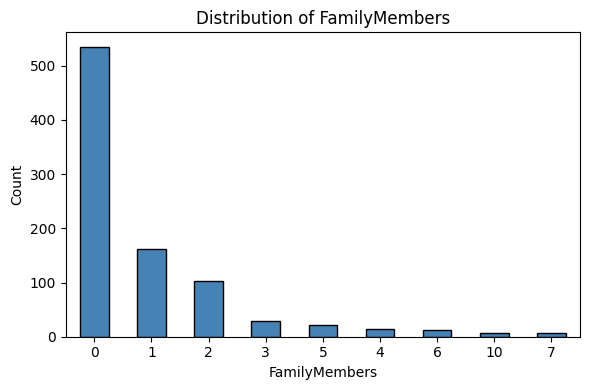

In [13]:
family_members= titanic_df["SibSp"]+titanic_df["Parch"]
titanic_df["FamilyMembers"]=family_members

print_bar_plot(titanic_df,"FamilyMembers")

Dodajemy kolumne okreąlającą czy pasazer podróżował sam:

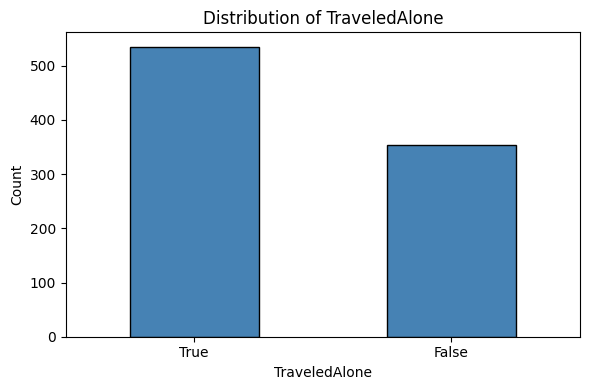

In [14]:
traveled_alone=titanic_df["FamilyMembers"]==0
titanic_df["TraveledAlone"]=traveled_alone

print_bar_plot(titanic_df,"TraveledAlone")

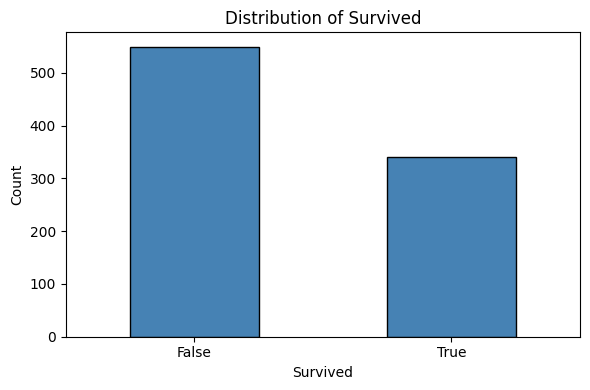

In [15]:
print_bar_plot(titanic_df,"Survived")

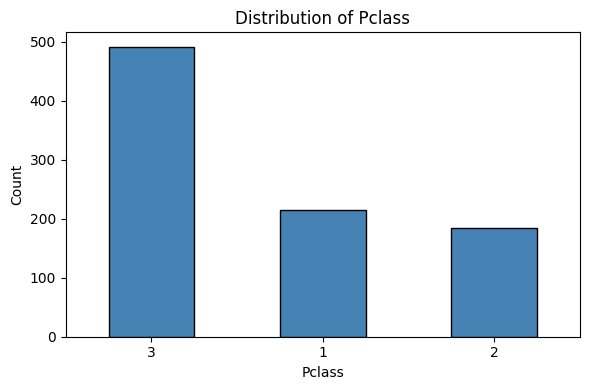

In [16]:
print_bar_plot(titanic_df,"Pclass")

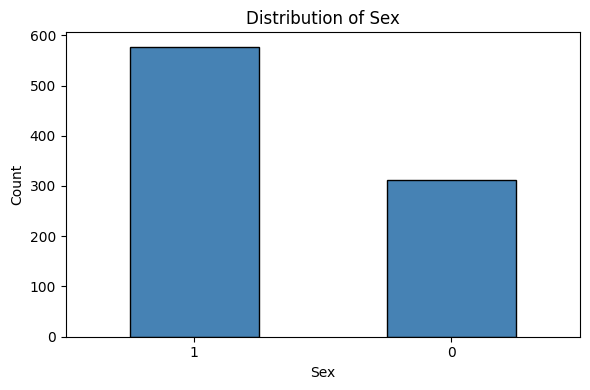

In [17]:
print_bar_plot(titanic_df,"Sex")

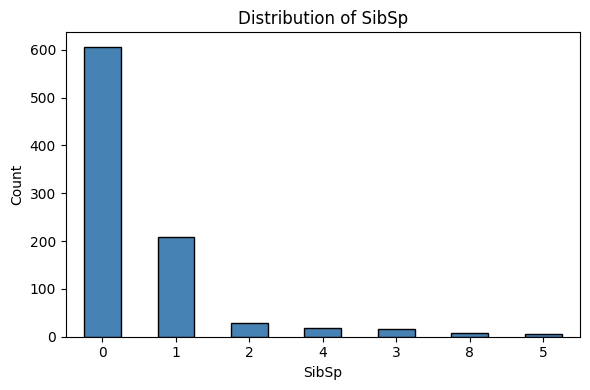

In [18]:
print_bar_plot(titanic_df,"SibSp")

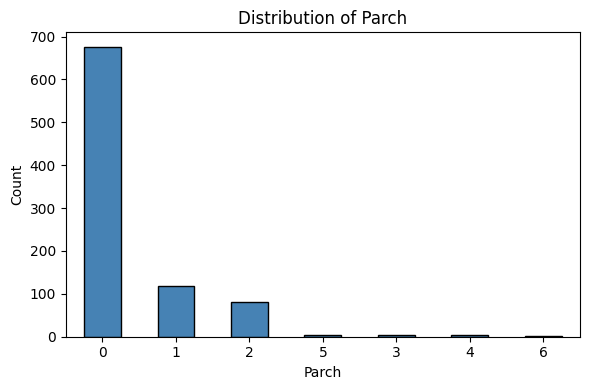

In [19]:
print_bar_plot(titanic_df,"Parch")

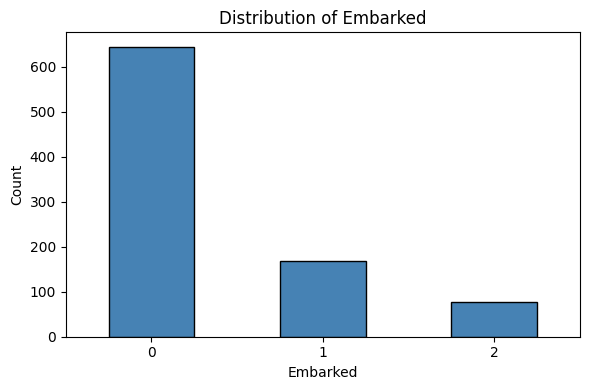

In [20]:
print_bar_plot(titanic_df,"Embarked")

Macież korelacji:

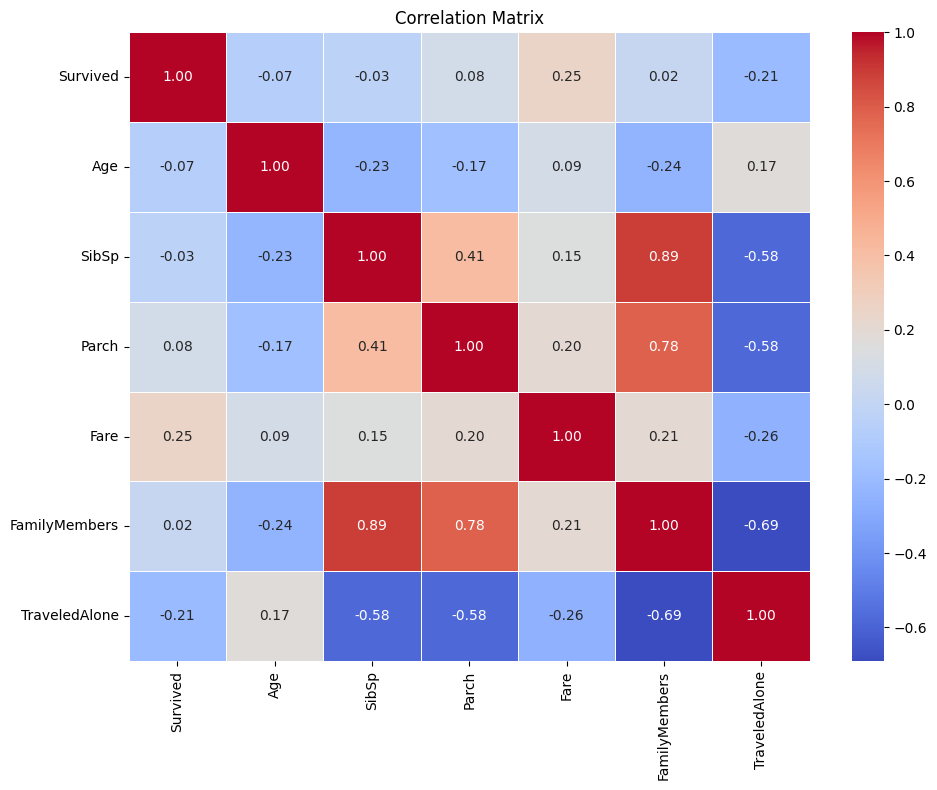

In [21]:
def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(titanic_df)

Widać korelacje między SibSp, Parch, FamilyMember oraz między Survived a Traveled alone i Fare.

In [22]:
def scatterplot(df, column_name, y):
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=column_name, y=y, color='darkorange', alpha=0.6)
    plt.title(f'{column_name} vs {y}')
    plt.xlabel(column_name)
    plt.ylabel('Charges')
    plt.tight_layout()
    plt.show()


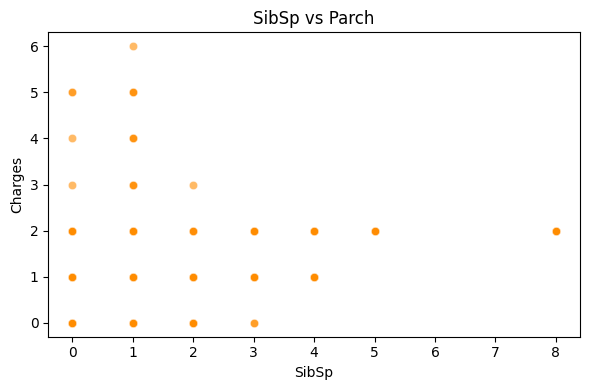

In [23]:
scatterplot(titanic_df, "SibSp", "Parch")

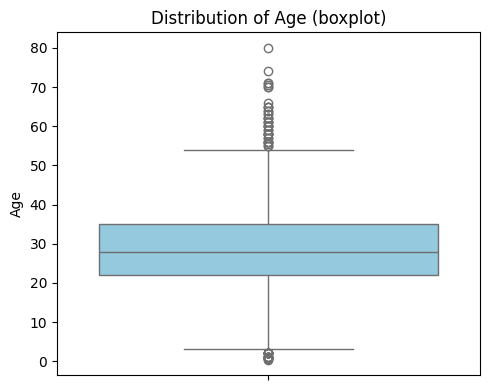

In [24]:


print_box_plot(titanic_df,"Age")

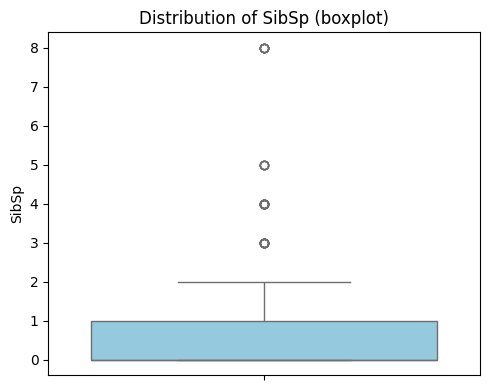

In [25]:
print_box_plot(titanic_df,"SibSp")

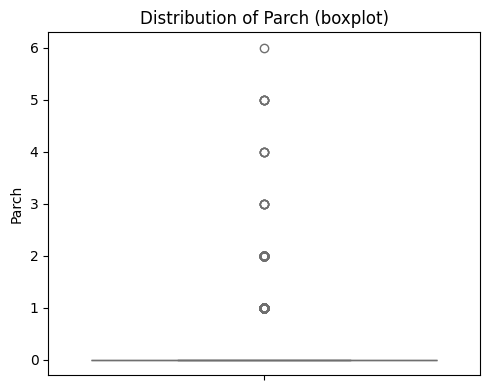

In [26]:
print_box_plot(titanic_df,"Parch")

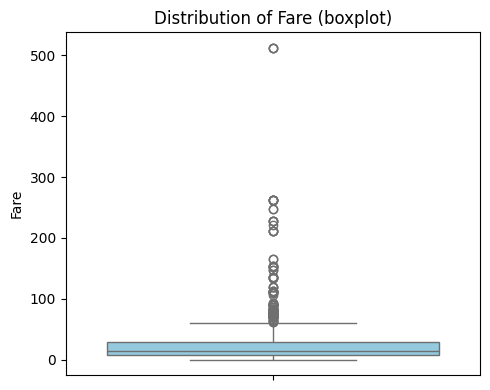

In [27]:
print_box_plot(titanic_df,"Fare")

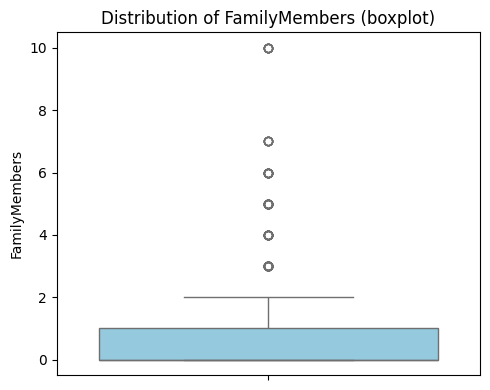

In [28]:
print_box_plot(titanic_df,"FamilyMembers")

We wszystkich powyzszych wykresach widać duzo wartości odstających.

Urzywamy robust scaler.

In [29]:
def robust_scaler(df, column_name):
  newdf=df.copy()
  q1 = df[column_name].quantile(0.25)
  q3 = df[column_name].quantile(0.75)
  iqr = q3 - q1
  median = df[column_name].median()

  if iqr == 0:
        iqr = 1.0

  newdf[column_name]= (df[column_name]-median)/iqr
  return newdf


In [30]:
titanic_df = robust_scaler(titanic_df,"Age")
titanic_df = robust_scaler(titanic_df,"SibSp")
titanic_df = robust_scaler(titanic_df,"Parch")
titanic_df = robust_scaler(titanic_df,"Fare")
titanic_df = robust_scaler(titanic_df,"FamilyMembers")
